In [1]:
import pandas as pd
import numpy as np
import io

print("Step 1: Reading and Cleaning the Raw Text File...")

# 1. File ko path halne (timro Kaggle ma vako path)
file_path = '/kaggle/input/datasets/shishirpuri/kamala-master-model/Hydrology/DGH DATA/DGH_586.txt' # Yaha aafno file ko exact naam hala

# 2. File lai line-by-line padhne
with open(file_path, 'r') as file:
    lines = file.readlines()

# 3. SMART FILTER: Jun line ma kamma (',') cha, tyo matra asali data ho!
# Baki sabai mathi ko kachara (text, years) automatic ignore huncha.
clean_lines = [line for line in lines if ',' in line]

# 4. Tyo safa lines lai eutai text block ma jodne
clean_text = "".join(clean_lines)

# 5. Pandas lai sidhai CSV jasari padhna lagaune (io.StringIO le text lai file jasto banaucha)
# Hamro data ma header chaina, tesaile aafai naam dine: 'dateTime' ra 'value'
df = pd.read_csv(io.StringIO(clean_text), header=None, names=['dateTime', 'value'])

# 6. Date format milaune (01/Jan/2006 lai Python le bujhne datetime banaune)
df['dateTime'] = pd.to_datetime(df['dateTime'], format='%d/%b/%Y')

# 7. DateTime lai index banaune (Time-series ko lagi jaruri)
df.set_index('dateTime', inplace=True)

print("✅ Data Loaded Successfully! Kachara text hatiskayo.")
print("\nFirst 5 rows of clean DataFrame:")
print(df.head())
print(f"\nTotal Data Points: {len(df)}")

Step 1: Reading and Cleaning the Raw Text File...
✅ Data Loaded Successfully! Kachara text hatiskayo.

First 5 rows of clean DataFrame:
            value
dateTime         
2014-01-01   1.56
2014-01-02   1.56
2014-01-03   1.55
2014-01-04   1.55
2014-01-05   1.55

Total Data Points: 3467


In [2]:
df.describe()

,value
count,3467.000000
mean,2.494554
std,0.748293
min,0.000000
25%,1.980000
50%,2.340000
75%,2.870000
max,10.330000


--- OUTLIER INVESTIGATION ---


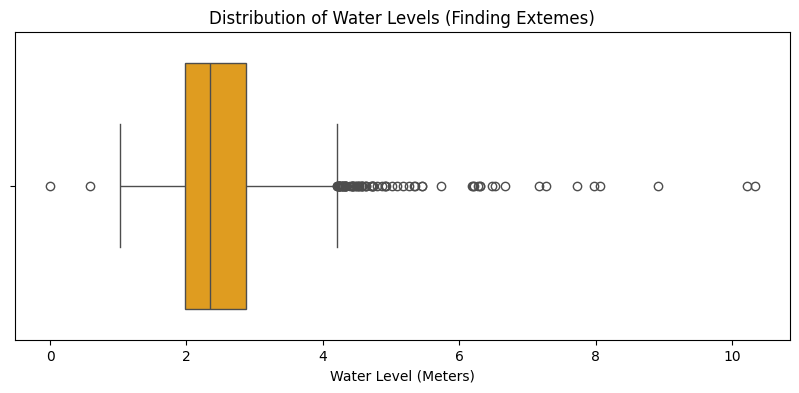


Mathematical Normal Range: 0.64m to 4.21m

--- TOP 10 LOWEST VALUES (Potential Sensor Drops) ---
            value
dateTime         
2015-07-17   0.00
2016-12-31   0.58
2018-12-31   1.03
2015-12-31   1.22
2014-04-24   1.30
2014-04-25   1.30
2014-04-26   1.30
2014-05-19   1.30
2014-05-20   1.30
2014-05-24   1.30

--- TOP 10 HIGHEST VALUES (Potential Floods or Glitches) ---
            value
dateTime         
2023-08-08  10.33
2019-07-12  10.22
2014-08-14   8.92
2021-07-03   8.06
2017-08-13   7.97
2019-07-13   7.73
2021-08-27   7.27
2020-07-21   7.17
2022-06-29   6.67
2021-07-01   6.53


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- OUTLIER INVESTIGATION ---")

# 1. Boxplot (Visualizing the extremes)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['value'], color='orange')
plt.title('Distribution of Water Levels (Finding Extemes)')
plt.xlabel('Water Level (Meters)')
plt.show()

# 2. IQR Method to find mathematical outliers
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nMathematical Normal Range: {lower_bound:.2f}m to {upper_bound:.2f}m")

# 3. Let's look at the SUSPICIOUS LOWS (Top 10 lowest values)
print("\n--- TOP 10 LOWEST VALUES (Potential Sensor Drops) ---")
print(df.nsmallest(10, 'value')[['value']])

# 4. Let's look at the EXTREME HIGHS (Floods vs Errors)
print("\n--- TOP 10 HIGHEST VALUES (Potential Floods or Glitches) ---")
print(df.nlargest(10, 'value')[['value']])

In [4]:
import pandas as pd
import numpy as np

print("--- STEP 1: REMOVING THE ZERO GLITCH ---")
# Tyo 0.00 meter (ya tyo bhanda tala ko kunai negative glitch) lai NaN banaune
df.loc[df['value'] <= 0.0, 'value'] = np.nan
print("✅ Sensor zero glitches replaced with NaN.")

print("\n--- STEP 2: FORCING A UNIFORM TIMELINE ---")
# 1. Hamro data ko suru ko din ra last ko din nikalne
start_date = df.index.min()
end_date = df.index.max()
print(f"Data Timeline: From {start_date.date()} to {end_date.date()}")

# 2. Euta perfect, continuous calendar banaune (1 day frequency)
full_timeline = pd.date_range(start=start_date, end=end_date, freq='D')

# 3. Hamro data lai yo perfect calendar sanga align (reindex) garne
# Jun din DHM le data deko chaina, tyaha Pandas le aafai NaN haldincha
df_uniform = df.reindex(full_timeline)
df_uniform.index.name = 'dateTime'

print("\n--- TIMELINE REPORT ---")
print(f"Original Data Points       : {len(df)}")
print(f"Uniform Timeline Points    : {len(df_uniform)}")
# Jati difference cha, teti ota 'hidden gaps' data ma thiyo
missing_days = df_uniform['value'].isna().sum()
print(f"Total Missing Days (NaNs)  : {missing_days}")

print("\n✅ Perfect Uniform Timeline Ready!")

--- STEP 1: REMOVING THE ZERO GLITCH ---
✅ Sensor zero glitches replaced with NaN.

--- STEP 2: FORCING A UNIFORM TIMELINE ---
Data Timeline: From 2014-01-01 to 2023-12-31

--- TIMELINE REPORT ---
Original Data Points       : 3467
Uniform Timeline Points    : 3652
Total Missing Days (NaNs)  : 186

✅ Perfect Uniform Timeline Ready!


In [5]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("--- STEP 3: SMART INTERPOLATION ---")
# 7 din samma ko gap (NaNs) lai linear interpolation le fill garne. 
# 7 din bhanda badi gap cha bhane teslai khali (NaN) chhod-dine.
gap_limit_days = 7
df_uniform['value'] = df_uniform['value'].interpolate(method='linear', limit=gap_limit_days)
print(f"Interpolation completed. Short gaps (<{gap_limit_days} days) filled.")


print("\n--- STEP 4: CHUNKING ALGORITHM (Breaking at Long Gaps) ---")
# Aba remaining NaNs (jun 7 din vanda lamo thiyo) ma data lai break garchau
def get_clean_chunks(df, min_len):
    chunks = []
    current_chunk = []
    for val in df['value'].values:
        if pd.notna(val):
            current_chunk.append(val)
        else:
            if len(current_chunk) > min_len:
                chunks.append(np.array(current_chunk))
            current_chunk = []
    if len(current_chunk) > min_len:
        chunks.append(np.array(current_chunk))
    return chunks

# Hamro daily lag time 10 days hune vako le, 10 din vanda sano chunk discard garchau
time_step = 10 
chunks = get_clean_chunks(df_uniform, min_len=time_step)

print(f"Data successfully split into {len(chunks)} continuous, safe chunks.")
for i in range(min(3, len(chunks))):
    print(f"  -> Chunk {i+1}: {len(chunks[i])} continuous days")


print("\n--- STEP 5: NORMALIZATION (MIN-MAX SCALING) ---")
# Harek chunk lai 0 dekhi 1 ko scale ma laane, tara fit euta global scaler bata garne
all_data_combined = np.concatenate(chunks).reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(all_data_combined) # Fits based on the overall Min and Max of the safe data

scaled_chunks = [scaler.transform(chunk.reshape(-1, 1)) for chunk in chunks]
print(f"Normalization Complete! Global Scale range is now 0.0 to 1.0.")

--- STEP 3: SMART INTERPOLATION ---
Interpolation completed. Short gaps (<7 days) filled.

--- STEP 4: CHUNKING ALGORITHM (Breaking at Long Gaps) ---
Data successfully split into 3 continuous, safe chunks.
  -> Chunk 1: 780 continuous days
  -> Chunk 2: 665 continuous days
  -> Chunk 3: 2040 continuous days

--- STEP 5: NORMALIZATION (MIN-MAX SCALING) ---
Normalization Complete! Global Scale range is now 0.0 to 1.0.


In [6]:
import numpy as np

print("--- STEP 6: DAILY WINDOW EXTRACTION (TIME_STEP=10) ---")

time_step = 10 # Model le past 10 days herera bholi ko guess garcha

def extract_windows(scaled_chunks, time_step):
    X_list, y_list = [], []
    for chunk in scaled_chunks:
        # Harek chunk bata windows banaune
        for i in range(len(chunk) - time_step):
            X_list.append(chunk[i:(i + time_step), 0]) # Past 10 days
            y_list.append(chunk[i + time_step, 0])     # Target (Next day)
    return np.array(X_list), np.array(y_list)

# Bagmati ko sequence generation
X_bagmati, y_bagmati = extract_windows(scaled_chunks, time_step)

# LSTM needs 3D input: [samples, time_steps, features]
# Features = 1 (Only Water Level)
X_bagmati = X_bagmati.reshape(X_bagmati.shape[0], X_bagmati.shape[1], 1)

print("✅ Bagmati Sequence Extraction Complete!")
print("-" * 40)
print(f"Total Sequences (Rows) : {len(X_bagmati)}")
print(f"Shape of X_bagmati     : {X_bagmati.shape} -> (Samples, 10 days, 1 feature)")
print(f"Shape of y_bagmati     : {y_bagmati.shape} -> (Samples,)")
print("-" * 40)

# VERY IMPORTANT: Delete large temporary variables to free up RAM before processing the next river
del df_uniform
del chunks
del scaled_chunks

--- STEP 6: DAILY WINDOW EXTRACTION (TIME_STEP=10) ---
✅ Bagmati Sequence Extraction Complete!
----------------------------------------
Total Sequences (Rows) : 3455
Shape of X_bagmati     : (3455, 10, 1) -> (Samples, 10 days, 1 feature)
Shape of y_bagmati     : (3455,) -> (Samples,)
----------------------------------------
